In [3]:
! pip install matplotlib

  Using cached matplotlib-3.10.8-cp313-cp313-macosx_11_0_arm64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp313-cp313-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.61.1-cp313-cp313-macosx_10_13_universal2.whl.metadata (114 kB)
  Using cached kiwisolver-1.4.9-cp313-cp313-macosx_11_0_arm64.whl.metadata (6.3 kB)
Using cached matplotlib-3.10.8-cp313-cp313-macosx_11_0_arm64.whl (8.1 MB)
Using cached contourpy-1.3.3-cp313-cp313-macosx_11_0_arm64.whl (274 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.61.1-cp313-cp313-macosx_10_13_universal2.whl (2.8 MB)
Using cached kiwisolver-1.4.9-cp313-cp313-macosx_11_0_arm64.whl (64 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 1.8 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]7 [matplotlib]

[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: 

In [8]:
class linreg:
    def __init__(self, alpha = 0.02, lambda_= 1e-5, iteration = 50):
        self.w = None
        self.alpha = alpha
        self.lambda_ = lambda_
        self.iteration = iteration
        self.loss_history = []

    def fit(self, X, y):
        m,n  = X.shape
        y = y.reshape(-1,1)
        self.w = np.zeros((n,1))
        for _ in range(self.iteration):
            y_pred = X @ self.w
            error = y_pred - y
            mse = (1 /(2 *m))* np.sum(error ** 2)
            l2_norm = (self.lambda_ /(2 *m)) * np.sum(self.w ** 2)
            loss = mse + l2_norm
            self.loss_history.append(loss)
            dw = (1/m)*(X.T @ error) + (self.lambda_/m) * self.w
            self.w -= self.alpha * dw

    def predict(self, X):
        y_pred = X @ self.w
        return y_pred


# Generate Dummy Data

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(42)

# Generate simple linear data
def generate_linear_data(n_samples=100, n_features=3, noise=0.1):
    """
    Generate synthetic linear regression data
    
    Parameters:
    - n_samples: number of data points
    - n_features: number of features (excluding bias)
    - noise: standard deviation of Gaussian noise
    
    Returns:
    - X: feature matrix with bias column (n_samples, n_features+1)
    - y: target vector (n_samples,)
    - true_w: true weights used to generate data
    """
    # Generate random features
    X = np.random.randn(n_samples, n_features)
    
    # Add bias column (column of ones)
    X = np.hstack([np.ones((n_samples, 1)), X])
    
    # Define true weights (including bias)
    true_w = np.array([2.0, 3.0, -1.5, 0.8])[:n_features+1]
    
    # Generate target with some noise
    y = X @ true_w + np.random.randn(n_samples) * noise
    
    return X, y, true_w

# Generate data
X_train, y_train, true_weights = generate_linear_data(n_samples=100, n_features=3, noise=0.5)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"True weights: {true_weights}")

X_train shape: (100, 4)
y_train shape: (100,)
True weights: [ 2.   3.  -1.5  0.8]


In [10]:
# Train the model
model = linreg(alpha=0.01, lambda_=0.01, iteration=1000)
model.fit(X_train, y_train)

In [12]:
# Make predictions
y_pred = model.predict(X_train)

# Evaluate
mse = np.mean((y_pred.ravel() - y_train)**2)
print(f"\nTraining Results:")
print(f"Iterations run: {len(model.loss_history)}")
print(f"Final loss: {model.loss_history[-1]:.6f}")
print(f"MSE: {mse:.6f}")


Training Results:
Iterations run: 1000
Final loss: 0.095395
MSE: 0.189204


In [13]:
print(f"\nLearned weights:\n{model.w.ravel()}")


Learned weights:
[ 2.05710093  2.95678662 -1.52548088  0.74521621]


In [14]:
print(f"True weights:\n{true_weights}")
print(f"Weight difference:\n{np.abs(model.w.ravel() - true_weights)}")

True weights:
[ 2.   3.  -1.5  0.8]
Weight difference:
[0.05710093 0.04321338 0.02548088 0.05478379]


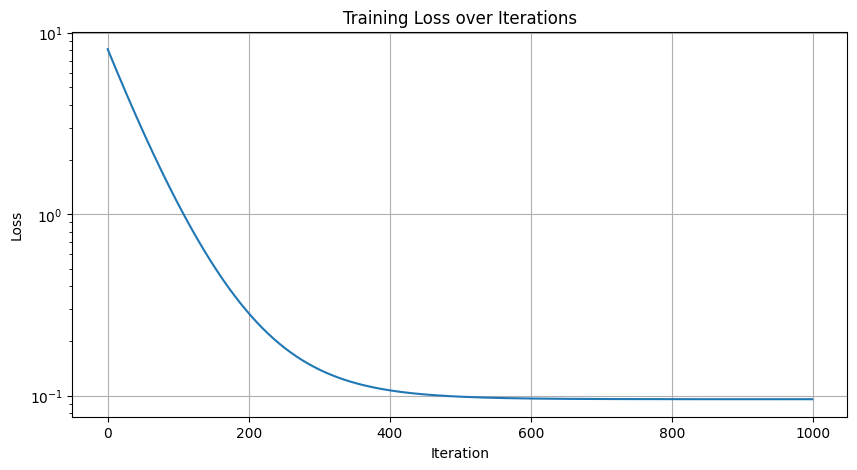

In [16]:
# Plot loss over iterations
plt.figure(figsize=(10, 5))
plt.plot(model.loss_history)
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Training Loss over Iterations')
plt.grid(True)
plt.yscale('log')  # Log scale to see convergence better
plt.show()